# Q-factorisation on Gridworld Maze Large

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy

from sklearn.decomposition import PCA

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
import torch.nn.functional as F
def get_base_env(env):
    return env.unwrapped

def collect_valid_states_fourrooms(env):

    base_env = get_base_env(env)

    if not hasattr(base_env, "_free_cells"):
        raise RuntimeError("Base env does not expose _free_cells.")

    coords = np.asarray(base_env._free_cells, dtype=np.int32)      # [N, 2]
    states = coords.astype(np.float32)                             # obs == (x, y)

    return states, coords

def shared_pca_projection(emb_before, emb_after, n_components=2):
    X = np.concatenate([emb_before, emb_after], axis=0)
    pca = PCA(n_components=n_components)
    Xp = pca.fit_transform(X)
    Z_before = Xp[:emb_before.shape[0]]
    Z_after = Xp[emb_before.shape[0]:]
    return Z_before, Z_after, pca

def plot_before_after(Z_before, Z_after, label_before, label_after, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z_before[:, 0], Z_before[:, 1], s=25, alpha=0.7, label=label_before)
    plt.scatter(Z_after[:, 0], Z_after[:, 1], s=25, alpha=0.7, label=label_after)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def estimate_fisher_diag(
    model,
    target_model,
    replay_buffer,
    goal,
    num_actions,
    device=DEVICE,
    gamma=0.99,
    batch_size=256,
    n_batches=64,
    prefix_filter="sa_encoder",
    use_success_only=False,
):
    """
    Estimate diagonal Fisher for EWC via TD loss on replay samples.

    If use_success_only is True, this assumes replay_buffer has a
    .sample_success(batch_size) method; otherwise it falls back to .sample.
    """

    model.eval()
    target_model.eval()

    fisher_diag = {}

    # Initialise Fisher entries for selected parameters
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if prefix_filter is None:
            fisher_diag[name] = torch.zeros_like(p, device=device)
        elif isinstance(prefix_filter, str):
            if name.startswith(prefix_filter):
                fisher_diag[name] = torch.zeros_like(p, device=device)
        else:
            if any(name.startswith(pref) for pref in prefix_filter):
                fisher_diag[name] = torch.zeros_like(p, device=device)

    if len(fisher_diag) == 0:
        raise ValueError("No parameters matched prefix_filter for Fisher estimation.")

    # Accumulate squared gradients
    num_batches_used = 0

    for _ in range(n_batches):
        if use_success_only and hasattr(replay_buffer, "sample_success"):
            batch = replay_buffer.sample_success(batch_size)
        else:
            batch = replay_buffer.sample(batch_size)

        obs_t = batch.obs          # [B, obs_dim]
        act_t = batch.actions.long()   # [B, 1]
        rew_t = batch.rewards      # [B, 1]
        next_obs_t = batch.next_obs
        term_t = batch.terminated
        trunc_t = batch.truncated
        done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)

        B = obs_t.shape[0]
        goal_batch = build_goal_batch(goal, B, device)

        with torch.no_grad():
            next_q_vals = target_model.q_val_for_argmax_action(next_obs_t, goal_batch)
            next_q = next_q_vals.max(dim=-1, keepdim=True).values
            target = rew_t + gamma * (1.0 - done_t) * next_q

        act_onehot = torch.nn.functional.one_hot(
            act_t.squeeze(-1),
            num_classes=num_actions
        ).float()

        current_q = model(obs_t, act_onehot, goal_batch)
        td_loss = torch.nn.functional.mse_loss(current_q, target)

        model.zero_grad(set_to_none=True)
        td_loss.backward()

        for name, p in model.named_parameters():
            if name in fisher_diag and p.grad is not None:
                fisher_diag[name] += p.grad.detach().pow(2)

        num_batches_used += 1

    if num_batches_used == 0:
        raise RuntimeError("No batches used in Fisher estimation.")

    # Average over batches
    for name in fisher_diag:
        fisher_diag[name] /= float(num_batches_used)

    # Per-parameter normalisation to stabilise scale
    eps = 1e-8
    for name, F in fisher_diag.items():
        mean_val = F.mean()
        if mean_val > 0:
            fisher_diag[name] = F / (mean_val + eps)

    scale = 10.0  # try 10, 50, etc.
    for name in fisher_diag:
        fisher_diag[name] = fisher_diag[name] * scale

    model.train()
    target_model.train()

    return fisher_diag

In [3]:
class FactorisedDQN_QNetwork(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int = 2,
        hidden_dim: int = 128,
        rep_dim: int = 64,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions
        self.goal_dim = goal_dim
        self.rep_dim = rep_dim

        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + self.action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        psi = self.goal_encoder(goal)
        psi = torch.tanh(psi)
        psi = F.normalize(psi, p=2, dim=-1, eps=1e-8)
        return psi

    def encode_state_action(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        sa = torch.cat([obs, act], dim=-1)
        phi = self.sa_encoder(sa)
        phi = torch.tanh(phi)
        phi = F.normalize(phi, p=2, dim=-1, eps=1e-8)
        return phi

    def forward(
        self,
        obs: torch.Tensor,
        act: torch.Tensor,
        goal: torch.Tensor,
    ) -> torch.Tensor:
        phi_sa = self.encode_state_action(obs, act)      # [B, D]
        psi_z = self.encode_goal(goal)                   # [B, D]
        q_vals = (phi_sa * psi_z).sum(dim=-1, keepdim=True)  # [B, 1]
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                        # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)   # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)             # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)          # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim)    # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat)    # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)                 # [B, A, D]

        psi_z = self.encode_goal(goal)                           # [B, D]
        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)           # [B, A, D]

        q_vals = (phi_sa * psi_rep).sum(dim=-1)                 # [B, A]
        return q_vals

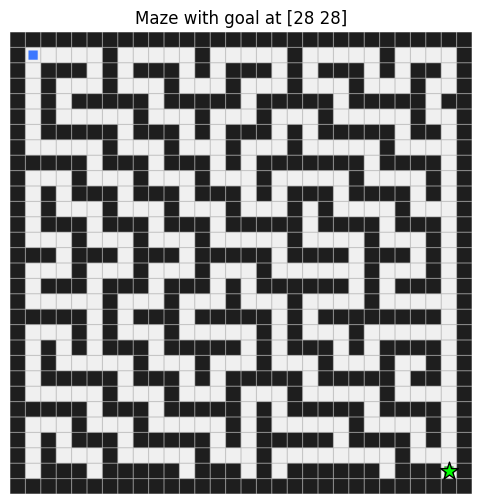

In [4]:
MAZE_LAYOUT_30 = [
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,1,0,1,0,1,1,1,0,1,0,1,1,1,0,1,0,1,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1],
    [1,0,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,1],
    [1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1],
    [1,0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,0,1,0,1,1,1,1,1,0,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1],
    [1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,0,1,1,1,1,1,1,1,0,1,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,1,1,0,1,1,1,0,1,0,1,1,1,0,1,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,1,1,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1],
    [1,0,1,1,1,0,1,1,1,0,1,1,1,0,1,0,1,1,1,1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,0,1,0,1,1,1,0,1,1,1,1,1,0,1,0,1,1,1,1,1,1,1,1,0,1],
    [1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1],
    [1,0,1,0,1,0,1,1,1,0,1,1,1,1,1,0,1,0,1,1,1,0,1,0,1,1,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,1],
    [1,0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1],
    [1,1,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,0,1,1,1,1,1,0,1,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,1,1,1,1,0,1,0,1,1,1,1,1,0,1,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,1,1,1,0,1,1,1,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(28, 28), slip_prob=0.00, max_horizon=1000):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT_30,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(28, 28))
obs, info = env.reset(options={"start_position": (1, 1)})

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

In [5]:
BUFFER_CAPACITY = 100000
GOAL = (9, 9)
LR = float(1e-3)

env = make_env(goal=GOAL)
obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n
task_embedding_memory = []


# Factorised Q-network instead of plain DQN_QNetwork
# Goal is 2-D (grid coordinates), so goal_dim=2
q_net = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)


def dqn_train(
    seed: int = 42,
    q_network=q_net,
    q_target_network=q_target,
    env=env,
    buffer_capacity=BUFFER_CAPACITY,
    lr=LR,
    obs_dim=obs_dim,
    device=DEVICE,
    total_steps=150000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=100000,
    train_freq=4,
    goal=GOAL,
    params=None,
    regulariser=None,
    reg_alpha=500,
    embedding_memory=task_embedding_memory,
    reference_params=None,
    fisher_diag=None,
    sa_reg_prefix_filter="sa_encoder",
    sigreg=1,
):
    set_seed(seed)

    if params is None:
        opt = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr},
            {"params": q_network.goal_encoder.parameters(), "lr": lr},
        ])
    else:
        opt = optim.Adam(params, lr=lr)

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset(options={"start_position": (1,1)})
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None
    ortho_loss = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    weight_loss = torch.tensor(0.0, device=device)
    ewc_loss = torch.tensor(0.0, device=device)
    loss = torch.tensor(0.0, device=device)

    ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
        [], [], [], [], [], []
    )

    num_actions = env.action_space.n

    while global_step < total_steps:
        frac = min(1.0, global_step / eps_decay_steps)
        eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t, goal_t_single)  # [1, A]
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        ep_obs.append(obs.copy())
        ep_actions.append(action)
        ep_rewards.append(float(rew))
        ep_next_obs.append(next_obs.copy())
        ep_terminated.append(float(term))
        ep_truncated.append(float(trunc))

        obs = next_obs
        global_step += 1

        if done:
            episode = {
                "obs": ep_obs,
                "actions": ep_actions,
                "rewards": ep_rewards,
                "next_obs": ep_next_obs,
                "terminated": ep_terminated,
                "truncated": ep_truncated,
            }
            buffer.add_episode(episode)
            ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
                [], [], [], [], [], []
            )
            obs, _ = env.reset(options={"start_position": (1, 1)})

        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs                    # [B, obs_dim]
            act_t = batch.actions.long()         # [B, 1]
            rew_t = batch.rewards                # [B, 1]
            next_obs_t = batch.next_obs          # [B, obs_dim]
            term_t = batch.terminated            # [B, 1]
            trunc_t = batch.truncated            # [B, 1]
            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)

            goal_batch = goal_t_single.expand(obs_t.shape[0], -1)   # [B, goal_dim]
            B = obs_t.shape[0]

            with torch.no_grad():
                next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)  # [B, A]
                next_q = next_q_vals.max(dim=-1, keepdim=True).values                            # [B, 1]
                target = rew_t + gamma * (1.0 - done_t) * next_q                                 # [B, 1]

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()                                                                            # [B, A]

            current_q = q_network(obs_t, act_onehot, goal_batch)                                 # [B, 1]
            td_loss = F.mse_loss(current_q, target)

            if sigreg is not None:
                act_onehot_all = F.one_hot(
                    torch.arange(num_actions, device=device),
                    num_classes=num_actions
                ).float()                                                                            # [A, A]
                act_onehot_all = act_onehot_all.unsqueeze(0).expand(B, -1, -1)                      # [B, A, A]

                obs_rep = obs_t.unsqueeze(1).expand(-1, num_actions, -1)                            # [B, A, obs_dim]
                obs_flat = obs_rep.reshape(B * num_actions, obs_dim)                                 # [B*A, obs_dim]
                act_flat = act_onehot_all.reshape(B * num_actions, num_actions)                      # [B*A, A]

                phi_all = q_network.encode_state_action(obs_flat, act_flat)                          # [B*A, D]
                sigreg_loss_val = sigreg_loss(phi_all)

            if reference_params is not None:
                weight_loss = weight_regulariser_loss(q_network, reference_params=reference_params, prefix_filter=sa_reg_prefix_filter)

            if fisher_diag is not None:
                ewc_loss = ewc_regulariser_loss(q_network, reference_params=reference_params, fisher_diag=fisher_diag, prefix_filter=sa_reg_prefix_filter)

            if regulariser is not None and regulariser == 'repulsion':
                #ortho_loss = orthogonal_loss(q_network, goal_t_single, embedding_memory, device)
                loss = td_loss + reg_alpha * ortho_loss + 0.1 * sigreg_loss_val + 0.1 * weight_loss + 10 * ewc_loss
            else:
                loss = td_loss + 0.1 * sigreg_loss_val + 10 * ewc_loss

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)
        
        if global_step % 1000 == 0 and reference_params is not None:
            delta_means = []
            for name, p in q_network.named_parameters():
                if name in reference_params:
                    delta_sq = (p.detach() - reference_params[name]).pow(2)
                    delta_means.append(delta_sq.mean().item())

            if len(delta_means) > 0:
                print("Mean squared deltas (first few):", delta_means[:5])

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            goal_eval_arr = np.array(goal, dtype=np.float32)
            goal_eval_t = torch.tensor(goal_eval_arr, dtype=torch.float32, device=device).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)  # [1, A]
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len = evaluate_policy(eval_env, eval_policy, episodes=8, options={"start_position": (1, 1)})
            eval_time = time.perf_counter() - start_time
            eval_returns_time.append((eval_time, mean_ret))
            eval_returns.append((global_step, mean_ret))
            print(
                f"[DQN-factorised] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
                f"| Ortho loss={ortho_loss.item():.3f} | SigReg loss={sigreg_loss_val.item():.3f} | Loss={loss.item():.3f}"
                f"| Weight loss={weight_loss.item():.3f} | EWC loss={ewc_loss.item():.10f}"
            )
            if mean_ret >= 0.99 and min_steps is None:
                min_steps = global_step
                min_time = eval_time
                print(f"Good policy achieved at step {global_step} with mean return {mean_ret:.3f}")
            eval_env.close()

    goal_tensor = torch.tensor(np.array(goal, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        psi_z = q_network.encode_goal(goal_tensor)   # [1, rep_dim]
        task_embedding = psi_z.squeeze(0).cpu().numpy()

    env.close()
    return (
        q_network,
        q_target_network,
        eval_returns,
        eval_returns_time,
        min_steps if 'min_steps' in locals() else None,
        min_time if 'min_time' in locals() else None,
        task_embedding,
        buffer
    )

def plot_eval_results(eval_first, eval_time_first, min_steps_first, min_time_first):
    if eval_first and eval_time_first:
        xs_steps, ys_steps = zip(*eval_first)
        xs_time, ys_time = zip(*eval_time_first)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(xs_steps, ys_steps)
        if min_steps_first is not None:
            ax1.axvline(min_steps_first, color='red', linestyle='--', label='Good policy achieved')
            ax1.annotate(
                f"Good policy achieved at step {min_steps_first}",
                xy=(min_steps_first, 0.99),
                xytext=(min_steps_first + 5000, 0.5),
                arrowprops=dict(arrowstyle="->", color='red'),
                color='red',
            )
        ax1.set_xlabel("Environment steps")
        ax1.set_ylabel("Mean episodic return")
        ax1.set_title("Q = φ(s,a)ᵀψ(z) on FourRooms (discrete) – steps")
        ax1.grid(alpha=0.25)
        
        ax2.plot(xs_time, ys_time)
        if min_time_first is not None:
            ax2.axvline(min_time_first, color='red', linestyle='--', label='Good policy achieved')
            ax2.annotate(
                f"Good policy achieved at time {min_time_first:.2f}s",
                xy=(min_time_first, 0.99),
                xytext=(min_time_first + 5.0, 0.5),
                arrowprops=dict(arrowstyle="->", color='red'),
                color='red',
            )
        ax2.set_xlabel("Evaluation time (s)")
        ax2.set_ylabel("Mean episodic return")
        ax2.set_title("Q = φ(s,a)ᵀψ(z) on FourRooms (discrete) – time")
        ax2.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

def print_goal_embedding_similarity(task_embedding_memory, goal_labels=None, decimals=3):
    if len(task_embedding_memory) == 0:
        print("Goal embedding memory is empty.")
        return

    M = np.stack(task_embedding_memory, axis=0)  # [N, D]
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-8)
    sim = M @ M.T  # cosine similarity matrix, [N, N]

    if goal_labels is None:
        goal_labels = [f"g{i}" for i in range(len(task_embedding_memory))]

    print("\nGoal embedding cosine similarity matrix:")
    header = " " + " ".join([f"{str(label):>10s}" for label in goal_labels])
    print(header)

    for i, row in enumerate(sim):
        row_str = " ".join([f"{x:10.{decimals}f}" for x in row])
        print(f"{str(goal_labels[i]):>8s} {row_str}")

    if len(task_embedding_memory) > 1:
        upper = sim[np.triu_indices(len(task_embedding_memory), k=1)]
        print(f"\nOff-diagonal mean similarity: {upper.mean():.{decimals}f}")
        print(f"Off-diagonal min similarity: {upper.min():.{decimals}f}")
        print(f"Off-diagonal max similarity: {upper.max():.{decimals}f}")



In [6]:
def visualise_q_table(goal, q_network, eval_returns=None):
    q_network.eval()
    eval_env_first = make_env(goal=goal)

    base_env = eval_env_first.unwrapped if hasattr(eval_env_first, "unwrapped") else eval_env_first
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])

    def dqn_policy_fn(obs, q_network, goal):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        goal_arr = np.array(goal, dtype=np.float32)
        goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            q_vals = q_network.q_val_for_argmax_action(obs_t, goal_t)
            action = int(q_vals.argmax(dim=-1).item())

        return action

    def dqn_value_fn(obs_batch, q_network, goal):
        obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
        B = obs_t.shape[0]

        goal_arr = np.array(goal, dtype=np.float32)
        goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        goal_batch = goal_t.expand(B, -1)

        with torch.no_grad():
            q_vals = q_network.q_val_for_argmax_action(obs_t.to(DEVICE), goal_batch.to(DEVICE)).cpu().numpy()

        return q_vals

    plot_policy_rollouts(
        env=eval_env_first,
        policy_fn=lambda obs: dqn_policy_fn(obs, q_network=q_network, goal=goal),
        goal_pos=goal,
        eval_episodes=8,
        n_cols=4,
        is_discrete=True,
        step_point_size=12,
        start_size=60,
        end_size=50,
        goal_size=130,
        arrow_width=0.01,
        reset_options={"start_position": (1, 1)}
    )

    plot_q_diagnostics(
        env=eval_env_first,
        value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=q_network, goal=goal),
        actor_fn=None,
        is_discrete=True,
        num_actions=eval_env_first.action_space.n,
        action_names=env_action_names,
        goal_pos=goal,
        eval_returns=eval_returns,
    )

    eval_env_first.close()
    q_network.train()

    return q_network

In [7]:

def visualise_embeddings(goal, q_network):
    eval_env_first = make_env(goal=goal)
    base_goal = np.array(goal, dtype=np.float32)
    base_goal_t = torch.tensor(base_goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    states_base, coords_base = collect_valid_states_fourrooms(eval_env_first)
    obs_base_t = torch.tensor(states_base, dtype=torch.float32, device=DEVICE)

    q_network.eval()
    with torch.no_grad():
        # No encode_state in the new class, so remove phi_s_base analysis
        psi_z_base = q_network.encode_goal(base_goal_t).cpu().numpy()  # [1, D]

        N = obs_base_t.shape[0]
        A = q_network.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=DEVICE),
            num_classes=q_network.action_dim
        ).float()                                                      # [A, A]

        obs_rep = obs_base_t.unsqueeze(1).expand(-1, A, -1)            # [N, A, obs_dim]
        act_rep = act_onehot.unsqueeze(0).expand(N, -1, -1)            # [N, A, A]

        obs_flat = obs_rep.reshape(N * A, q_network.obs_dim)           # [N*A, obs_dim]
        act_flat = act_rep.reshape(N * A, q_network.action_dim)        # [N*A, A]

        phi_sa_base = q_network.encode_state_action(obs_flat, act_flat).cpu().numpy()  # [N*A, D]
        phi_sa_base = phi_sa_base.reshape(N, A, q_network.rep_dim)     # [N, A, D]

    N_base, A_base, D_base = phi_sa_base.shape
    phi_sa_base_flat = phi_sa_base.reshape(N_base * A_base, D_base)

    print("states_base:", states_base.shape)
    print("coords_base:", coords_base.shape)
    print("phi(s,a) base:", phi_sa_base.shape)
    print("psi(z) base:", psi_z_base.shape)

    # Convert to torch
    phisa_t = torch.tensor(phi_sa_base_flat, dtype=torch.float32)
    psi_t   = torch.tensor(psi_z_base.squeeze(0), dtype=torch.float32)  # [D]

    # 1) Norm statistics
    norms = phisa_t.norm(dim=-1)   # [N*A]
    print(f"phi(s,a) norms: mean={norms.mean().item():.4f}, std={norms.std().item():.4f}")

    # 2) Effective rank (via singular values)
    phisa_centered = phisa_t - phisa_t.mean(dim=0, keepdim=True)
    U, S, Vh = torch.linalg.svd(phisa_centered, full_matrices=False)
    S_np = S.cpu().numpy()
    explained = (S_np ** 2) / (S_np ** 2).sum()
    cumulative = explained.cumsum()

    print("top 5 singular values:", S_np[:5])
    print("cumulative variance (first 5 dims):", cumulative[:5])

    psi_unit = psi_t / (psi_t.norm() + 1e-8)
    phisa_unit = phisa_t / (phisa_t.norm(dim=-1, keepdim=True) + 1e-8)

    # 2) Compute cosine similarities
    cos = phisa_unit @ psi_unit  # [N*A]
    cos_np = cos.cpu().numpy()

    print(f"cos(phi(s,a), psi): mean={cos_np.mean():.4f}, std={cos_np.std():.4f}")

    # 3) Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: Variance spectrum
    axes[0].plot(cumulative, marker="o")
    axes[0].set_xlabel("Number of components")
    axes[0].set_ylabel("Cumulative variance explained")
    axes[0].set_title(f"Variance spectrum of phi(s,a) [{goal}]")
    axes[0].grid(alpha=0.3)

    # Right: Cosine similarity histogram
    axes[1].hist(cos_np, bins=40, alpha=0.7)
    axes[1].set_xlabel("cos(phi(s,a), psi(z))")
    axes[1].set_ylabel("count")
    axes[1].set_title(f"Cosine histo phi(s,a) vs psi(z) [{goal}]")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    eval_env_first.close()


## Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(7, 7) -----

[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-99.600 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-99.600 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-99.600 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.962 | eval_return=-99.600 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.953 | eval_return=-99.600 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
[DQN-factorised] step=   6000 | eps=0.943

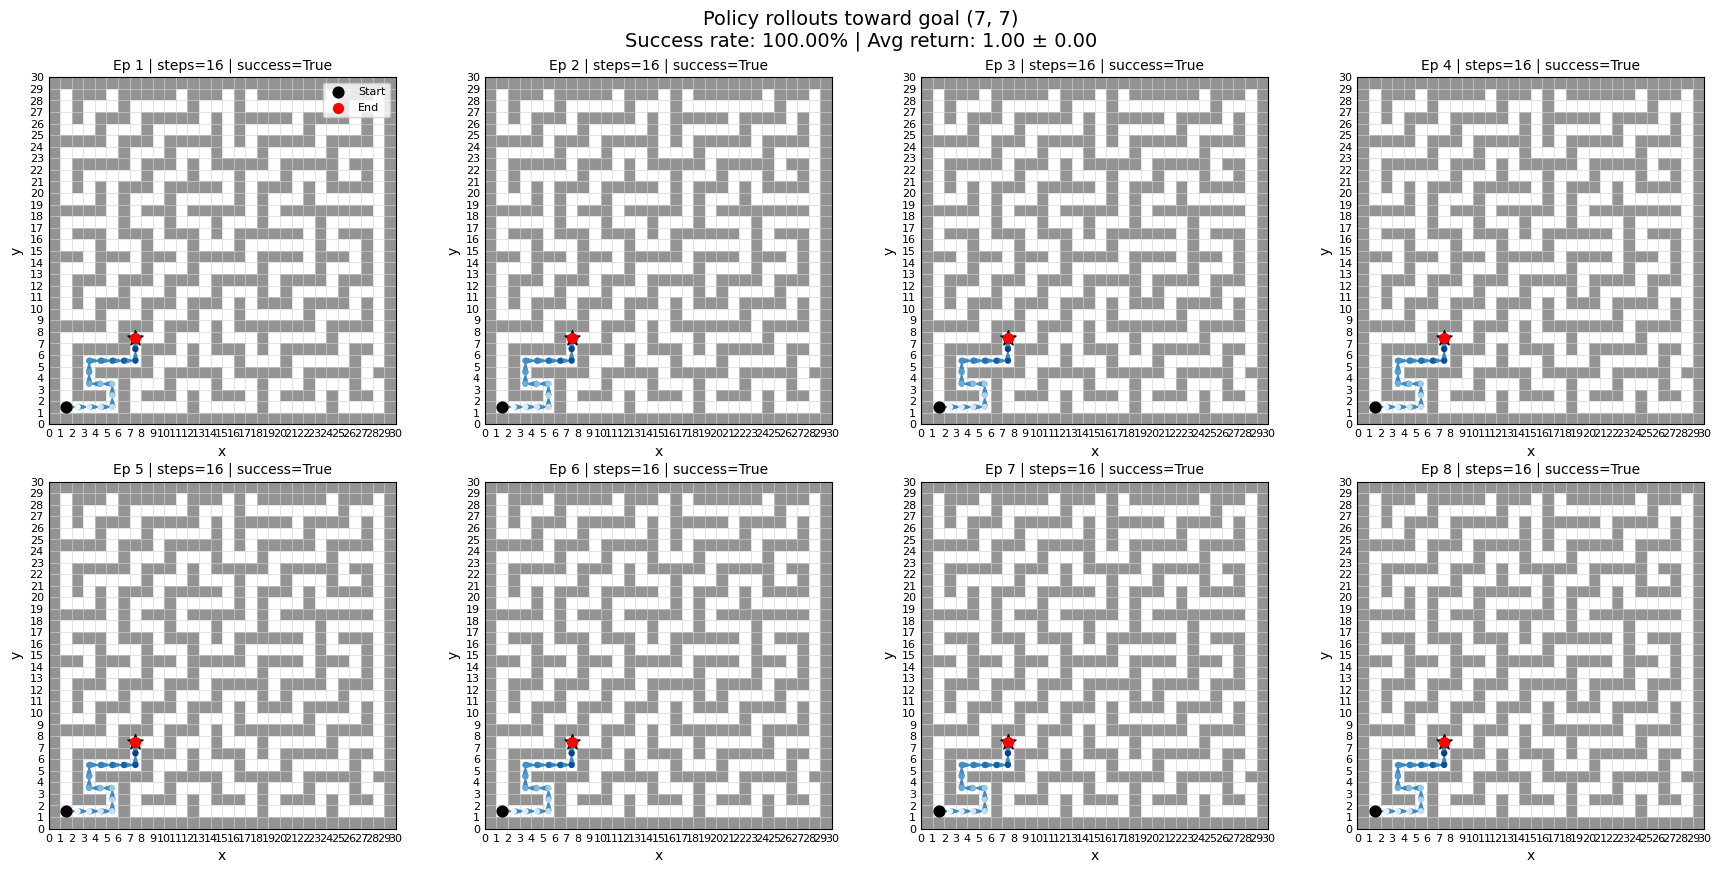

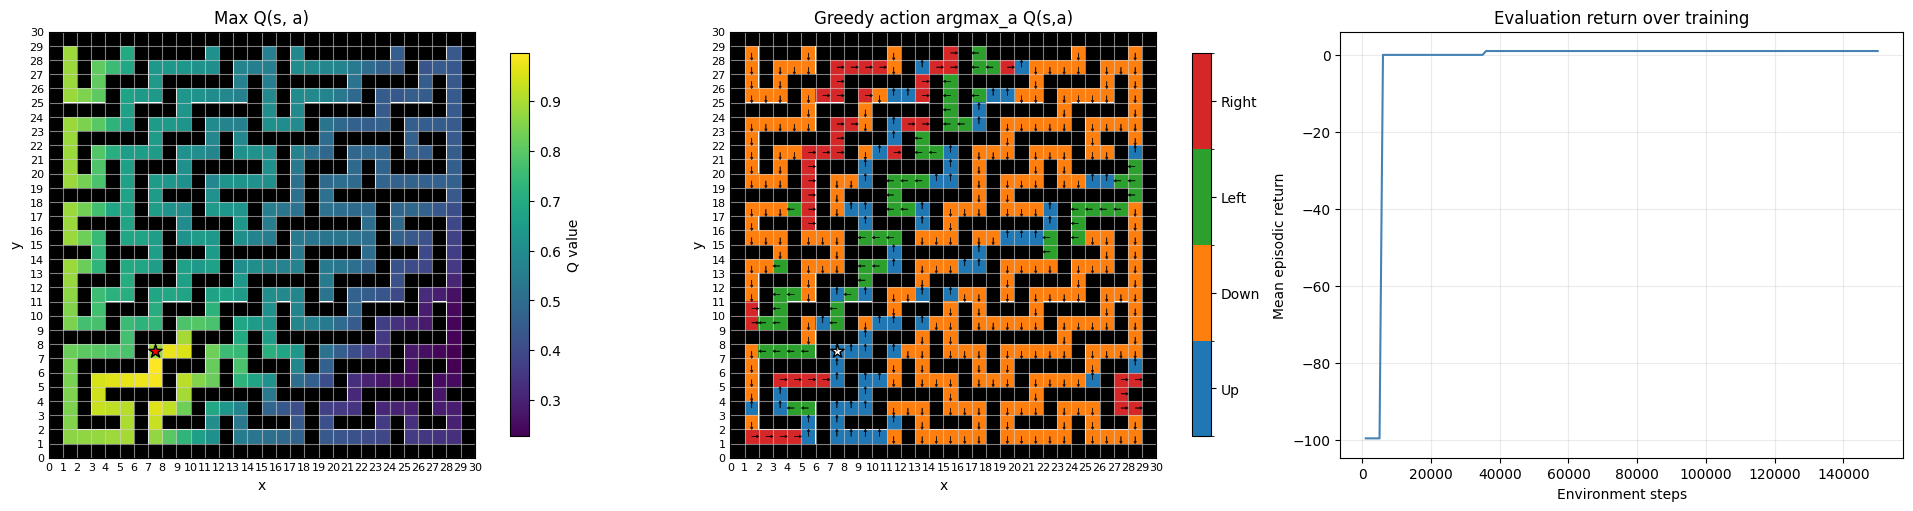

states_base: (415, 2)
coords_base: (415, 2)
phi(s,a) base: (415, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [18.213154 11.600273  7.715184  6.383008  4.329223]
cumulative variance (first 5 dims): [0.4930139  0.6930117  0.78147876 0.8420323  0.86988765]
cos(phi(s,a), psi): mean=0.5401, std=0.1825


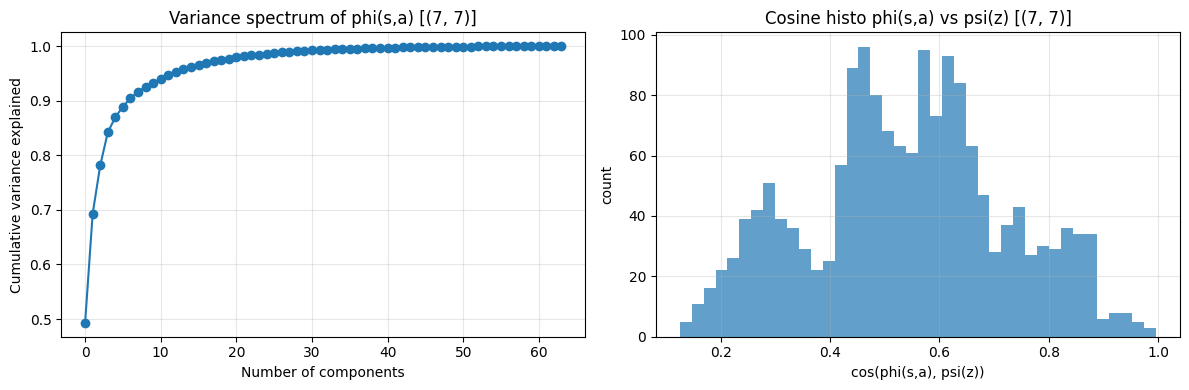


Goal embedding cosine similarity matrix:
     (7, 7)
  (7, 7)      1.000
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 7.371209621429443

----- seed=42, goal=(17, 13) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-98.400 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-98.400 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-98.400 | eval_len=1000.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   4000 | eps=0.962 | eval_

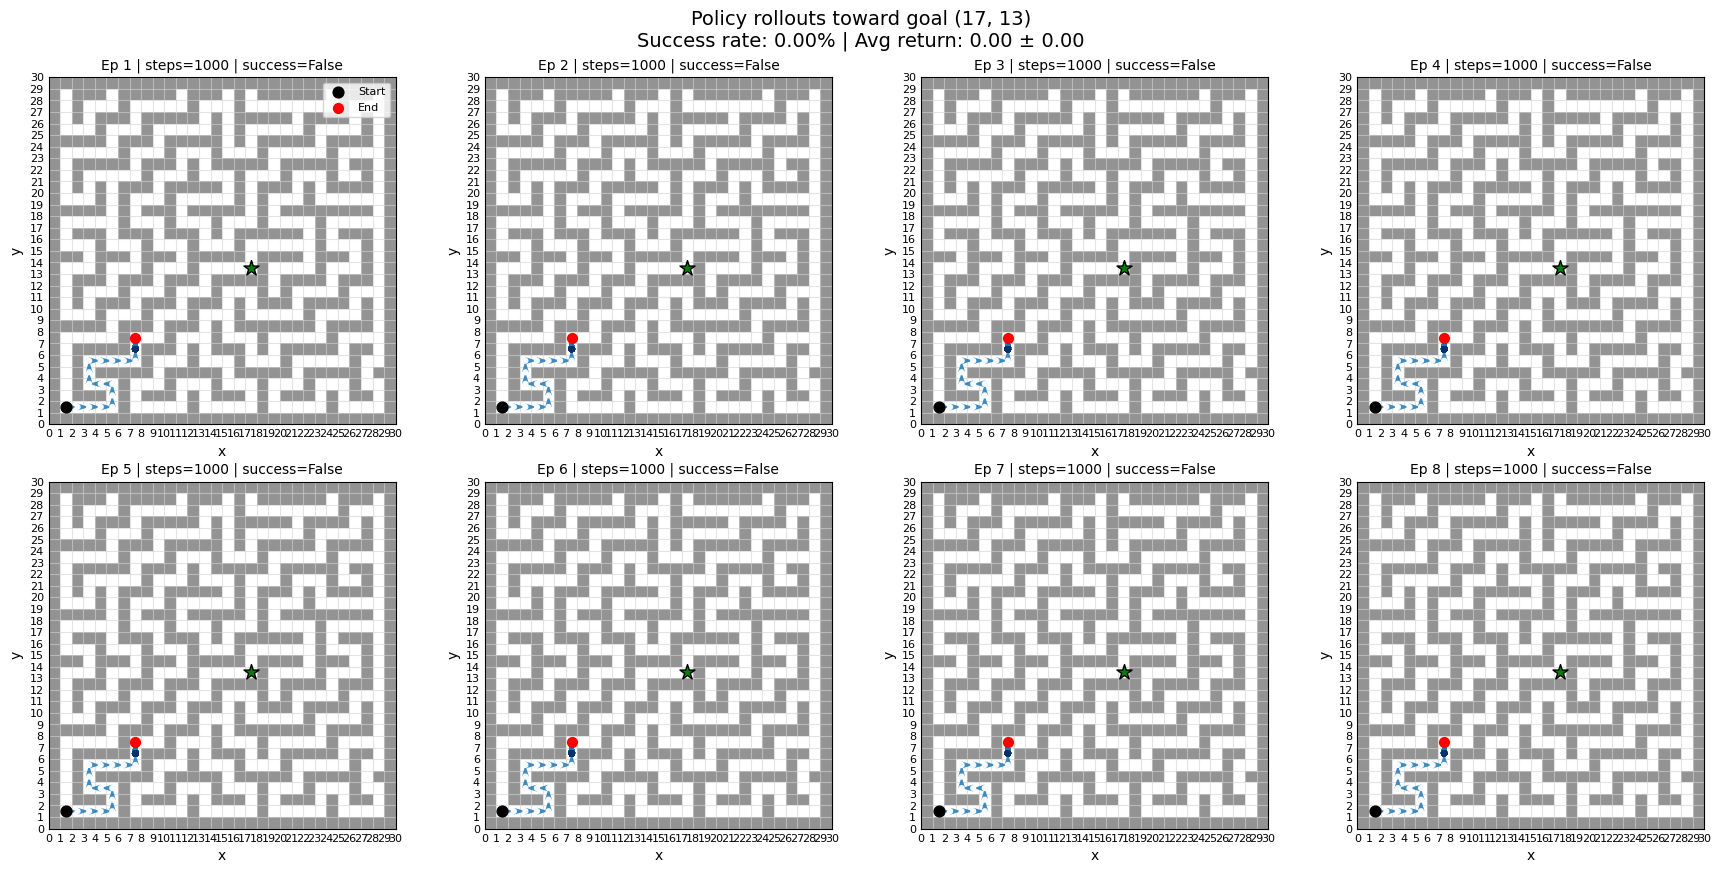

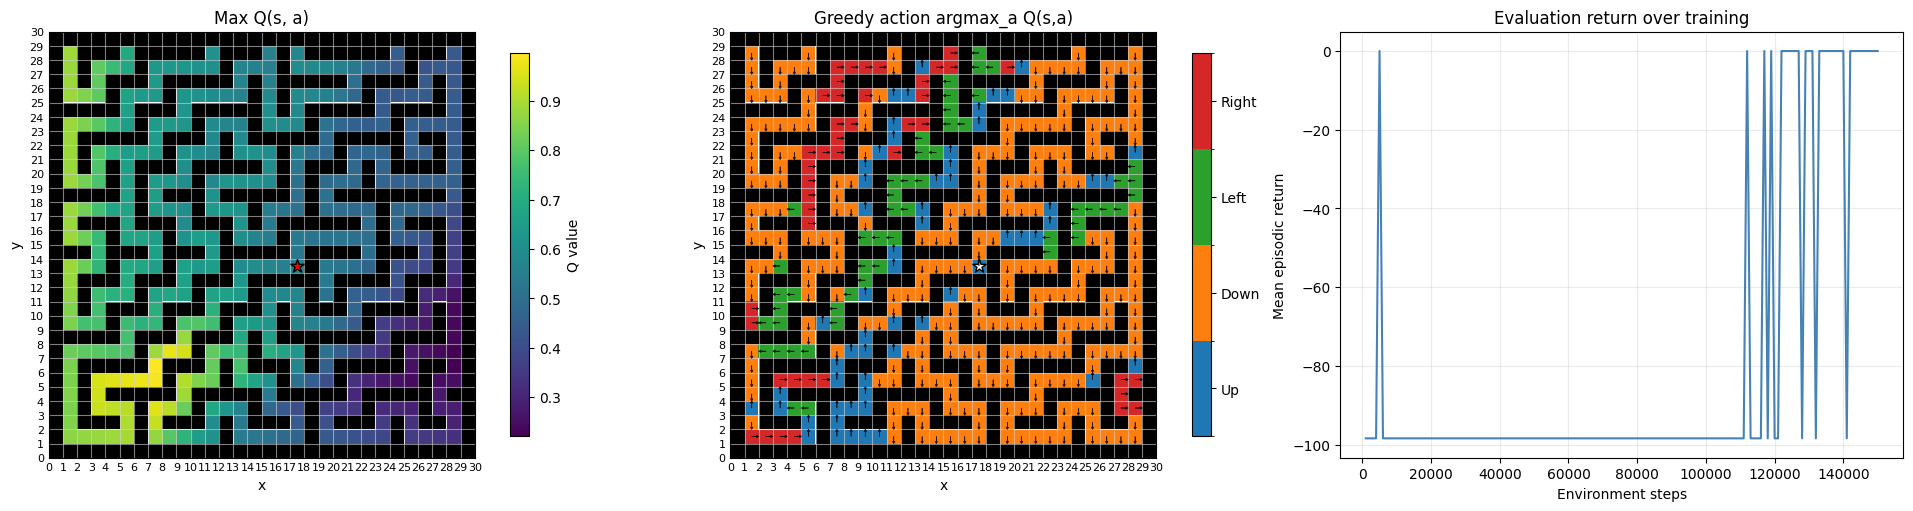

states_base: (415, 2)
coords_base: (415, 2)
phi(s,a) base: (415, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [18.16322   11.610213   7.6933537  6.3578253  4.2942677]
cumulative variance (first 5 dims): [0.4922243  0.6933455  0.78165525 0.841966   0.8694801 ]
cos(phi(s,a), psi): mean=0.5367, std=0.1827


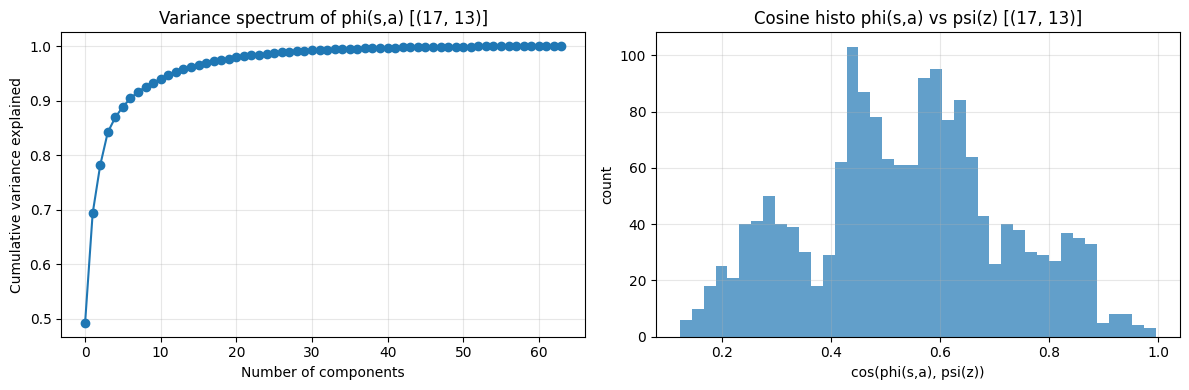


Goal embedding cosine similarity matrix:
     (7, 7)   (17, 13)
  (7, 7)      1.000      1.000
(17, 13)      1.000      1.000

Off-diagonal mean similarity: 1.000
Off-diagonal min similarity: 1.000
Off-diagonal max similarity: 1.000
EWC params: 9152 Total params: 17792
ref len: 4
fisher len: 4
sample F value: 9.997964859008789


In [8]:
SEEDS = [42]
GOALS = [(7, 7), (17,13)]

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)  # your helper

    # Create env to get obs_dim, num_actions once
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # One network per seed, reused across goals
    q_net = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)
    q_target.load_state_dict(q_net.state_dict())
    for p in q_target.parameters():
        p.requires_grad_(False)

    base_goal_encoder_state = deepcopy(q_net.goal_encoder.state_dict())
    # base_obs_last_layer_state = deepcopy(q_net.obs_encoder[-1].state_dict())

    # Per-seed task embedding memory (for repulsion)
    seed_task_embedding_memory = []
    seen_goal_labels = []
    prev_reference_params = None
    prev_fisher_diag = None
    prev_goal = None
    prev_buffer = None


    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        # Resync target to current q_net before training on this goal
        q_target.load_state_dict(q_net.state_dict())
        for p in q_target.parameters():
            p.requires_grad_(False)

        # q_net.goal_encoder.load_state_dict(base_goal_encoder_state)
        # q_target.goal_encoder.load_state_dict(base_goal_encoder_state)

        # q_net.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)
        # q_target.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)

        # Decide which params to train (transfer vs. full)
        if goal_idx == 0:
            # First goal: train full network
            for p in q_net.parameters():
                p.requires_grad_(True)
            trainable_params = None  # let dqn_train create its usual optimizer
            regulariser = None
            reference_params = None
            fisher_diag = None
        else:

            for p in q_net.parameters():
                p.requires_grad_(True)
            # Subsequent goals: reuse phi, train only psi (and optionally last phi layer)
            # for p in q_net.sa_encoder.parameters():
            #     p.requires_grad_(False)
            # for p in q_net.goal_encoder.parameters():
            #     p.requires_grad_(True)

            # # If you want psi + last phi layer instead of only psi:
            # last_layer = list(q_net.sa_encoder.children())[-1]
            # for p in last_layer.parameters():
            #     p.requires_grad_(True)

            trainable_params = [p for p in q_net.parameters() if p.requires_grad]
            regulariser = "repulsion"  # or None if you don’t want repulsion here

        # Train on this goal, reusing q_net weights from previous goals
        q_net, q_target, eval_returns, eval_returns_time, min_steps, min_time, task_embedding, buffer= dqn_train(
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            goal=goal,
            device=DEVICE,
            embedding_memory=seed_task_embedding_memory,  # previous task embeddings in this seed
            regulariser=regulariser,
            reg_alpha=1,          # your choice 
            params=trainable_params, # None for full training, list for transfer mode
            reference_params=prev_reference_params,
            fisher_diag=prev_fisher_diag,
            sa_reg_prefix_filter="sa_encoder",
        )
        visualise_q_table(goal, q_net, eval_returns=eval_returns)
        visualise_embeddings(goal, q_net)   
        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

        prev_reference_params = snapshot_named_parameters(q_net, prefix_filter="sa_encoder")
        prev_fisher_diag = estimate_fisher_diag(
                model=q_net,
                target_model=q_target,
                replay_buffer=buffer,
                goal=goal,
                num_actions=num_actions,
                device=DEVICE,
                gamma=0.99,
                batch_size=256,
                n_batches=64,
                prefix_filter="sa_encoder"
        )

        ewc_param_count = sum(
            p.numel() for name, p in q_net.named_parameters()
            if name in prev_reference_params
        )
        total_param_count = sum(p.numel() for p in q_net.parameters())

        print("EWC params:", ewc_param_count, "Total params:", total_param_count)

        print("ref len:", len(prev_reference_params))
        if prev_fisher_diag is not None:
            print("fisher len:", len(prev_fisher_diag))
            some_key = next(iter(prev_fisher_diag.keys()))
            print("sample F value:", prev_fisher_diag[some_key].abs().mean().item())

        prev_goal = goal
        prev_buffer = buffer

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)

### Plotting the curves

In [9]:
# def aggregate_curves(curves):
#     curves = [c for c in curves if c is not None and len(c) > 0]
#     if len(curves) == 0:
#         return None, None, None

#     x_grid = np.array([x for x, _ in curves[0]], dtype=np.float32)
#     ys_interp = []
#     for curve in curves:
#         xs = np.array([x for x, _ in curve], dtype=np.float32)
#         ys = np.array([y for _, y in curve], dtype=np.float32)
#         ys_interp.append(np.interp(x_grid, xs, ys))
#     ys_interp = np.stack(ys_interp, axis=0)

#     mean_y = ys_interp.mean(axis=0)
#     std_y = ys_interp.std(axis=0)
#     return x_grid, mean_y, std_y

# for goal in GOALS:
#     goal_res = overall_results[goal]

#     x_steps, mean_ret_steps, std_ret_steps = aggregate_curves(goal_res["eval_returns"])
#     x_time, mean_ret_time, std_ret_time = aggregate_curves(goal_res["eval_returns_time"])

#     min_steps_list = [s for s in goal_res["min_steps"] if s is not None]
#     min_time_list = [t for t in goal_res["min_time"] if t is not None]

#     print(f"\n==== Aggregated results for goal {goal} ====")
#     if len(min_steps_list) > 0:
#         print(f"Good-policy step (mean±std): {np.mean(min_steps_list):.1f} ± {np.std(min_steps_list):.1f}")
#     else:
#         print("Good-policy step: None")

#     if len(min_time_list) > 0:
#         print(f"Good-policy time (mean±std): {np.mean(min_time_list):.2f}s ± {np.std(min_time_list):.2f}s")
#     else:
#         print("Good-policy time: None")

#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#     # Left: steps plot
#     if x_steps is not None:
#         axes[0].plot(x_steps, mean_ret_steps, label="Mean over seeds")
#         axes[0].fill_between(
#             x_steps,
#             mean_ret_steps - std_ret_steps,
#             mean_ret_steps + std_ret_steps,
#             alpha=0.25,
#         )
#         axes[0].set_xlabel("Environment steps")
#         axes[0].set_ylabel("Mean episodic return")
#         axes[0].set_title(f"Goal {goal} (steps)")
#         axes[0].grid(alpha=0.25)
#         axes[0].legend()
#     else:
#         axes[0].set_title(f"Goal {goal} (steps)")
#         axes[0].text(0.5, 0.5, "No step data", ha="center", va="center")
#         axes[0].set_axis_off()

#     # Right: time plot
#     if x_time is not None:
#         axes[1].plot(x_time, mean_ret_time, label="Mean over seeds")
#         axes[1].fill_between(
#             x_time,
#             mean_ret_time - std_ret_time,
#             mean_ret_time + std_ret_time,
#             alpha=0.25,
#         )
#         axes[1].set_xlabel("Evaluation time (s)")
#         axes[1].set_ylabel("Mean episodic return")
#         axes[1].set_title(f"Goal {goal} (time)")
#         axes[1].grid(alpha=0.25)
#         axes[1].legend()
#     else:
#         axes[1].set_title(f"Goal {goal} (time)")
#         axes[1].text(0.5, 0.5, "No time data", ha="center", va="center")
#         axes[1].set_axis_off()

#     plt.tight_layout()
#     plt.show()

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

Episode 1: 1000 steps | return: 0.00 | reached goal: False
Episode 2: 1000 steps | return: 0.00 | reached goal: False
Episode 3: 1000 steps | return: 0.00 | reached goal: False
Episode 4: 1000 steps | return: 0.00 | reached goal: False
Episode 5: 1000 steps | return: 0.00 | reached goal: False
Episode 6: 1000 steps | return: 0.00 | reached goal: False
Episode 7: 1000 steps | return: 0.00 | reached goal: False
Episode 8: 1000 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


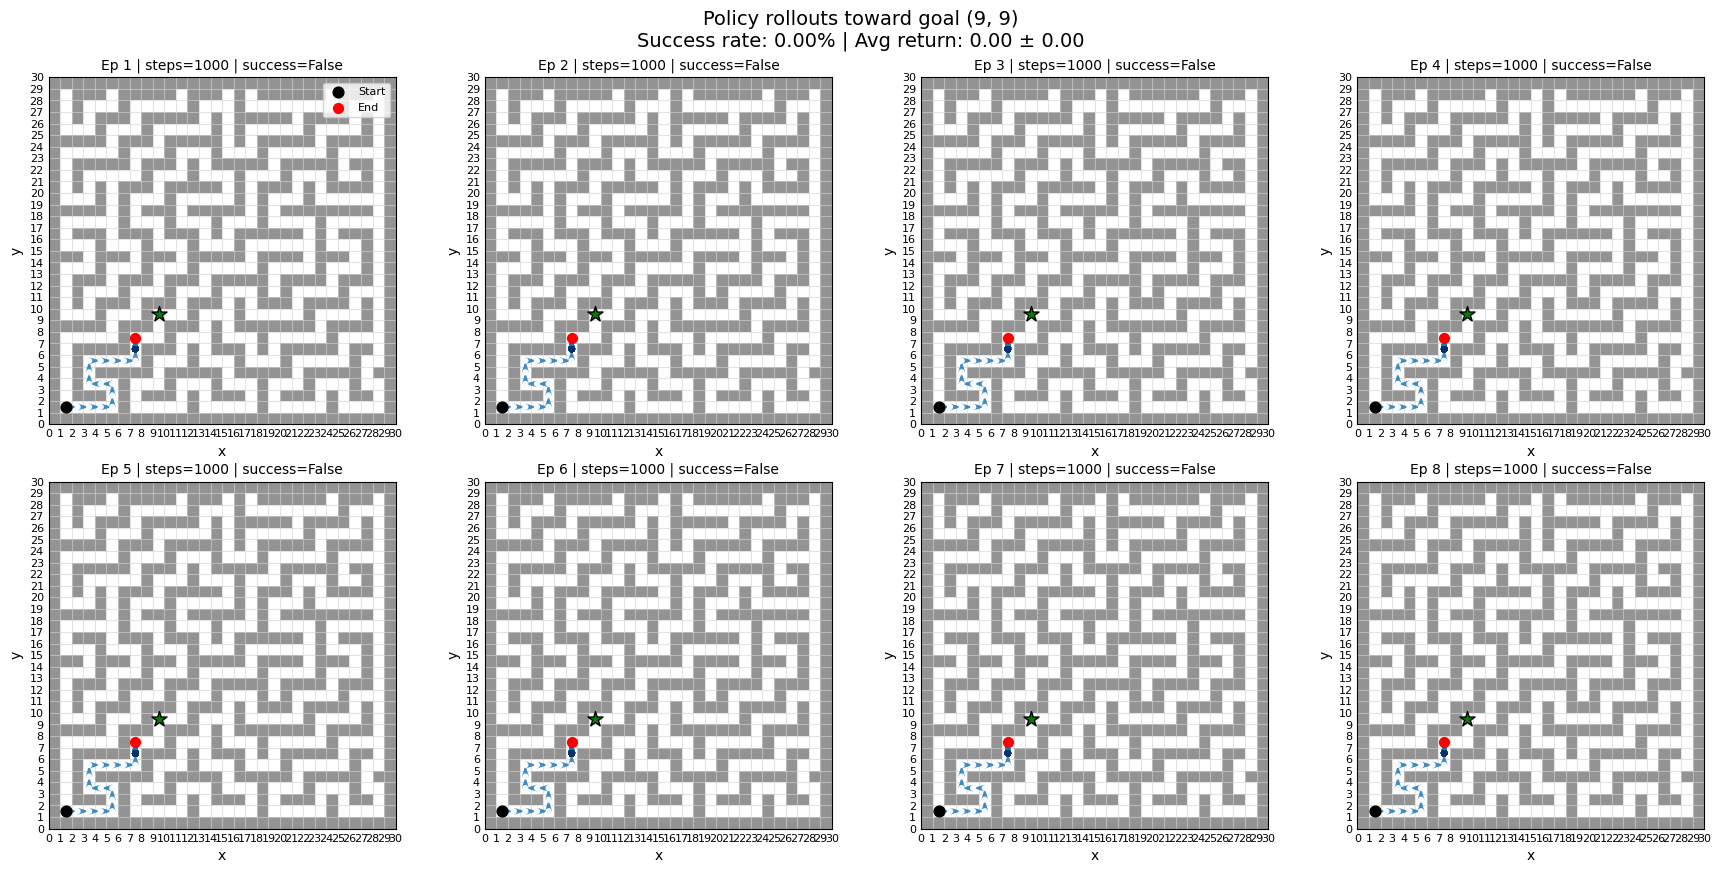

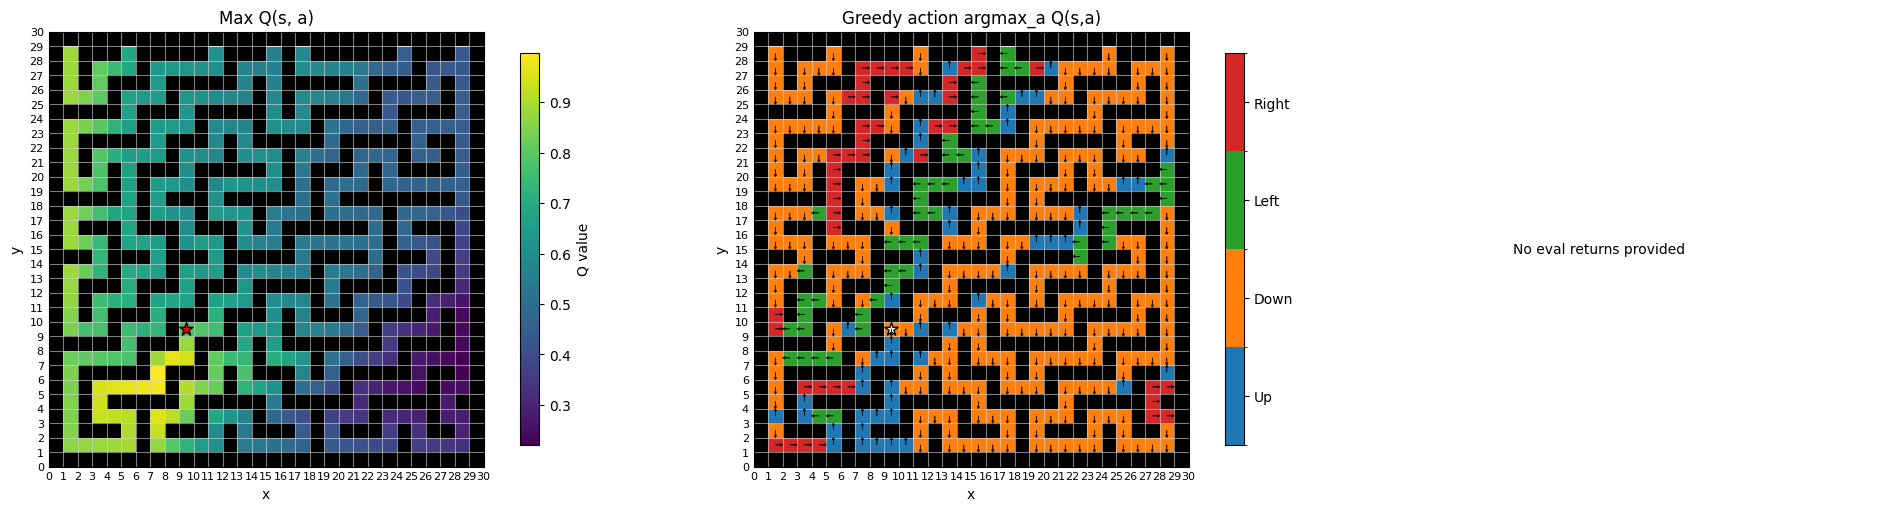

states_base: (415, 2)
coords_base: (415, 2)
phi(s,a) base: (415, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [18.16322   11.610213   7.6933537  6.3578253  4.2942677]
cumulative variance (first 5 dims): [0.4922243  0.6933455  0.78165525 0.841966   0.8694801 ]
cos(phi(s,a), psi): mean=0.5367, std=0.1827


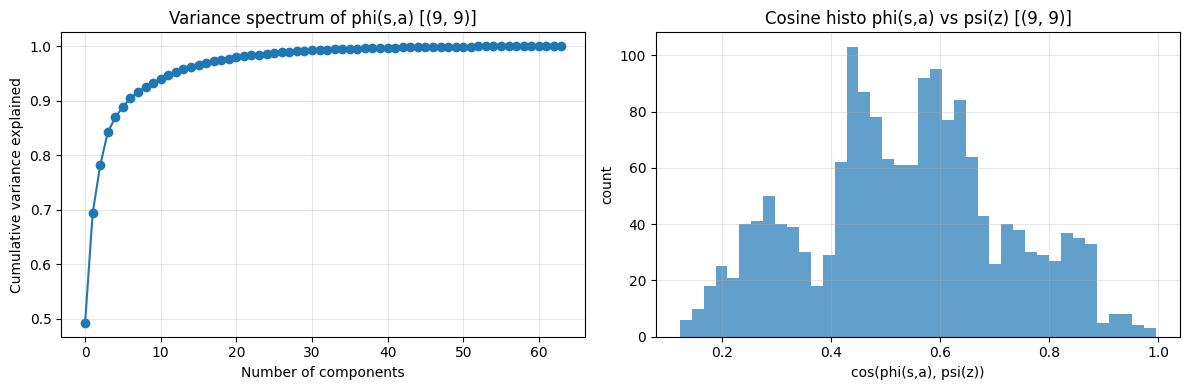

Episode 1: 1000 steps | return: 0.00 | reached goal: False
Episode 2: 1000 steps | return: 0.00 | reached goal: False
Episode 3: 1000 steps | return: 0.00 | reached goal: False
Episode 4: 1000 steps | return: 0.00 | reached goal: False
Episode 5: 1000 steps | return: 0.00 | reached goal: False
Episode 6: 1000 steps | return: 0.00 | reached goal: False
Episode 7: 1000 steps | return: 0.00 | reached goal: False
Episode 8: 1000 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


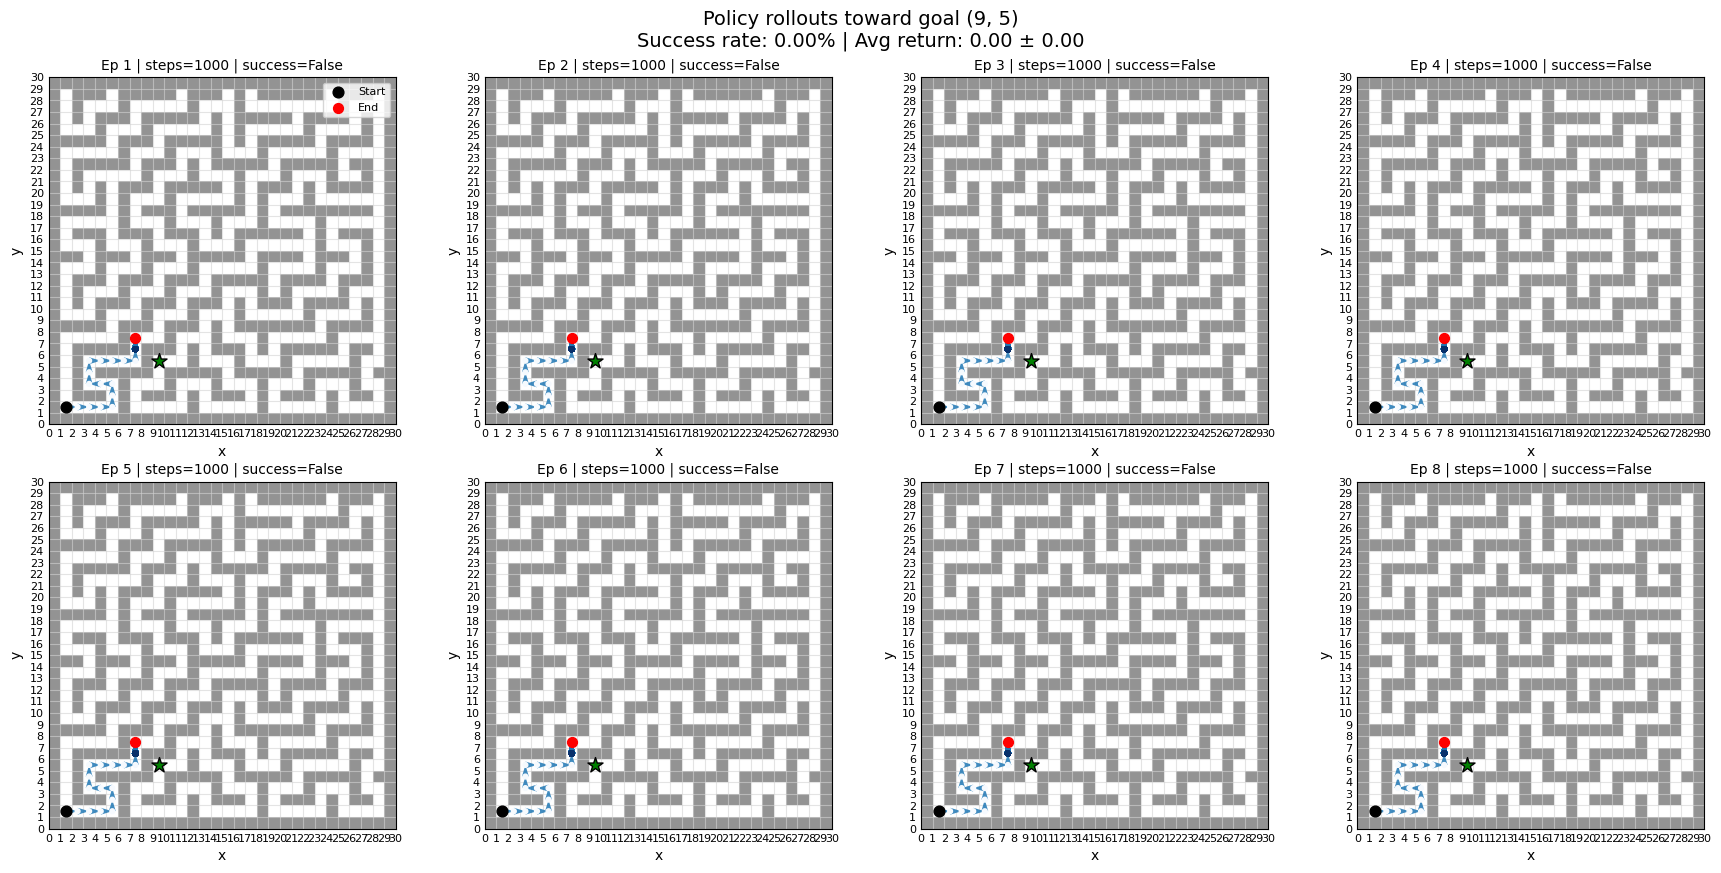

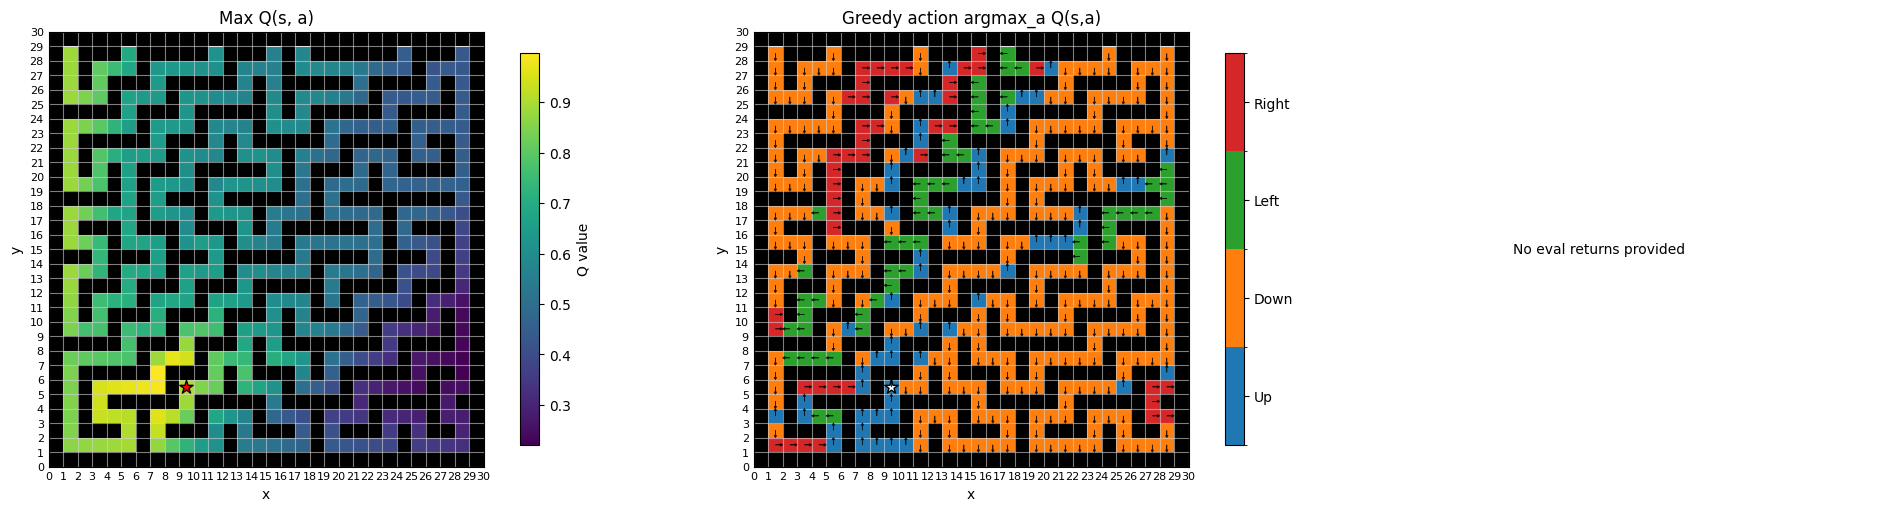

states_base: (415, 2)
coords_base: (415, 2)
phi(s,a) base: (415, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [18.16322   11.610213   7.6933537  6.3578253  4.2942677]
cumulative variance (first 5 dims): [0.4922243  0.6933455  0.78165525 0.841966   0.8694801 ]
cos(phi(s,a), psi): mean=0.5367, std=0.1827


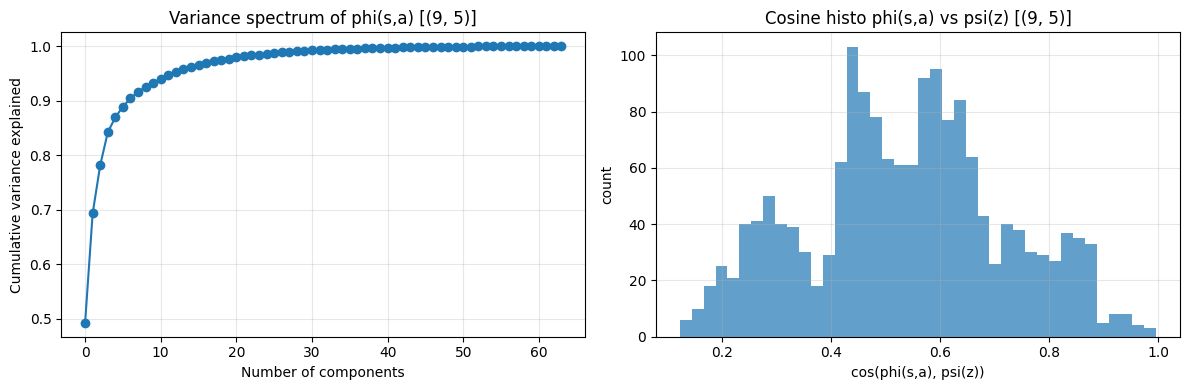

ValueError: Goal lies in wall cell: [6 2]

In [10]:
GOALS = [(9, 9), (9, 5), (6, 2), (1,7)]

for goal in GOALS:

    if goal not in overall_results:   
        overall_results[goal] = {
            "eval_returns": [],
            "eval_returns_time": [],
            "min_steps": [],
            "min_time": [],
            "task_embeddings": [],
        }

    new_task_embedding = q_net.goal_encoder(torch.tensor(np.array(goal, dtype=np.float32), dtype=torch.float32, device=DEVICE).unsqueeze(0)).squeeze(0).cpu().detach().numpy()
    overall_results[goal]["task_embeddings"].append(new_task_embedding)

    visualise_q_table(goal, q_net, eval_returns=None)
    visualise_embeddings(goal, q_net)   



In [ ]:
def plot_task_embeddings_and_qnet_weights_html(
    overall_results,
    qnet,
    mode="mean",   # "mean", "last", or "all"
    normalise=True,
    annotate=False,
    title_3d="Task embeddings in 3D PCA space",
    title_weights="Q-network weight distributions",
    save_3d_html="task_embeddings_3d.html",
    save_weights_html="qnet_weight_distributions.html",
    sa_keywords="sa_encoder",
    goal_keywords="goal_encoder",
    bins=80,
):
    import numpy as np
    import torch
    from sklearn.decomposition import PCA
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    def _to_numpy_embedding(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        x = np.asarray(x, dtype=np.float32)
        return x.reshape(-1)

    # ---------------------------
    # Part 1: 3D PCA embeddings
    # ---------------------------
    vectors = []
    labels = []
    goal_names = []

    for goal, data in overall_results.items():
        emb_list = data.get("task_embeddings", [])
        if len(emb_list) == 0:
            continue

        emb_list_np = [_to_numpy_embedding(e) for e in emb_list]

        if mode == "mean":
            vec = np.mean(np.stack(emb_list_np, axis=0), axis=0)
            vectors.append(vec)
            labels.append(str(goal))
            goal_names.append(str(goal))

        elif mode == "last":
            vec = emb_list_np[-1]
            vectors.append(vec)
            labels.append(str(goal))
            goal_names.append(str(goal))

        elif mode == "all":
            for i, vec in enumerate(emb_list_np):
                vectors.append(vec)
                labels.append(f"{goal} | idx={i}")
                goal_names.append(str(goal))
        else:
            raise ValueError("mode must be one of: 'mean', 'last', 'all'")

    if len(vectors) < 2:
        raise ValueError("Need at least 2 embeddings to run PCA.")

    X = np.stack(vectors, axis=0)

    if normalise:
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    pca = PCA(n_components=3)
    X_3d = pca.fit_transform(X)
    explained = pca.explained_variance_ratio_

    print("Explained variance ratio:", explained)
    print("Total explained by 3 PCs:", explained.sum())

    unique_goals = sorted(list(set(goal_names)))
    palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
    ]
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(unique_goals)}

    fig_3d = go.Figure()

    for goal in unique_goals:
        idxs = [i for i, g in enumerate(goal_names) if g == goal]
        xs = X_3d[idxs, 0]
        ys = X_3d[idxs, 1]
        zs = X_3d[idxs, 2]
        texts = [labels[i] for i in idxs]
        color = color_map[goal]

        for x, y, z in zip(xs, ys, zs):
            fig_3d.add_trace(go.Scatter3d(
                x=[0, x], y=[0, y], z=[0, z],
                mode="lines",
                line=dict(color=color, width=5),
                opacity=0.7,
                showlegend=False,
                hoverinfo="skip"
            ))

        fig_3d.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="markers+text" if annotate else "markers",
            text=texts if annotate else None,
            textposition="top center",
            marker=dict(size=6, color=color, opacity=0.95),
            name=goal,
            hovertext=texts,
            hovertemplate="label=%{hovertext}<br>PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}<extra></extra>",
            textfont=dict(size=10)
        ))

    fig_3d.add_trace(go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode="markers",
        marker=dict(size=5, color="black", symbol="x"),
        name="origin",
        hovertemplate="origin<extra></extra>"
    ))

    fig_3d.update_layout(
        title=title_3d,
        scene=dict(
            xaxis_title=f"PC1 ({explained[0]*100:.1f}%)",
            yaxis_title=f"PC2 ({explained[1]*100:.1f}%)",
            zaxis_title=f"PC3 ({explained[2]*100:.1f}%)",
            aspectmode="cube"
        ),
        template="plotly_white",
        legend=dict(x=1.02, y=1.0),
        margin=dict(l=0, r=0, t=50, b=0)
    )

    fig_3d.write_html(save_3d_html, include_plotlyjs=True)
    fig_3d.show()

    # -----------------------------------------
    # Part 2: Weight distributions for qnet
    # -----------------------------------------
    sa_weights = []
    goal_weights = []
    sa_names = []
    goal_names_params = []
    other_names = []

    for name, param in qnet.named_parameters():
        if not param.requires_grad:
            continue

        vals = param.detach().cpu().numpy().ravel()
        lname = name.lower()

        if any(k in lname for k in sa_keywords):
            sa_weights.append(vals)
            sa_names.append(name)
        elif any(k in lname for k in goal_keywords):
            goal_weights.append(vals)
            goal_names_params.append(name)
        else:
            other_names.append(name)

    if len(sa_weights) == 0 and len(goal_weights) == 0:
        raise ValueError(
            "No matching parameters found. Adjust sa_keywords and goal_keywords "
            "to match your qnet.named_parameters() names."
        )

    fig_w = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("SA encoder weights", "Goal encoder weights")
    )

    summary = {}

    if len(sa_weights) > 0:
        sa_all = np.concatenate(sa_weights)
        fig_w.add_trace(
            go.Histogram(
                x=sa_all,
                nbinsx=bins,
                marker_color="#1f77b4",
                opacity=0.8,
                name="SA encoder"
            ),
            row=1, col=1
        )
        summary["sa_encoder"] = {
            "num_tensors": len(sa_weights),
            "num_params": int(sa_all.size),
            "mean": float(sa_all.mean()),
            "std": float(sa_all.std()),
            "min": float(sa_all.min()),
            "max": float(sa_all.max()),
            "matched_names": sa_names,
        }
        print(
            f"[SA encoder] n={sa_all.size}, mean={sa_all.mean():.6f}, "
            f"std={sa_all.std():.6f}, min={sa_all.min():.6f}, max={sa_all.max():.6f}"
        )

    if len(goal_weights) > 0:
        goal_all = np.concatenate(goal_weights)
        fig_w.add_trace(
            go.Histogram(
                x=goal_all,
                nbinsx=bins,
                marker_color="#ff7f0e",
                opacity=0.8,
                name="Goal encoder"
            ),
            row=1, col=2
        )
        summary["goal_encoder"] = {
            "num_tensors": len(goal_weights),
            "num_params": int(goal_all.size),
            "mean": float(goal_all.mean()),
            "std": float(goal_all.std()),
            "min": float(goal_all.min()),
            "max": float(goal_all.max()),
            "matched_names": goal_names_params,
        }
        print(
            f"[Goal encoder] n={goal_all.size}, mean={goal_all.mean():.6f}, "
            f"std={goal_all.std():.6f}, min={goal_all.min():.6f}, max={goal_all.max():.6f}"
        )

    fig_w.update_xaxes(title_text="Weight value", row=1, col=1)
    fig_w.update_xaxes(title_text="Weight value", row=1, col=2)
    fig_w.update_yaxes(title_text="Count", row=1, col=1)
    fig_w.update_yaxes(title_text="Count", row=1, col=2)
    fig_w.update_layout(
        title=title_weights,
        template="plotly_white",
        bargap=0.05,
        showlegend=False,
        margin=dict(l=40, r=40, t=70, b=40)
    )

    fig_w.write_html(save_weights_html, include_plotlyjs=True)
    fig_w.show()

    summary["other_params"] = other_names

    return {
        "X_original": X,
        "X_3d": X_3d,
        "labels": labels,
        "goal_names": goal_names,
        "pca": pca,
        "explained_variance_ratio": explained,
        "fig_3d": fig_3d,
        "fig_weights": fig_w,
        "weights_summary": summary,
        "save_3d_html": save_3d_html,
        "save_weights_html": save_weights_html,
    }

In [ ]:
plot_task_embeddings_3d(
    overall_results,
    mode="all",
    normalise=True,
    annotate=False,
    show_legend=True,
    title="All task embeddings across seeds"
)